# Exercise-01: Build a LSTM based predictor (using Keras) to predict the stock price of NVIDIA

In [1]:
# Author: Francesco Esposito (fe.digi@cbs.dk)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [2]:
# alternative keras imports
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, LSTM

In [3]:
# Load the data
dataset = pd.read_csv('nvda_5yr.csv')
dataset = dataset.iloc[::-1].reset_index(drop=True)  # reverse order: oldest -> newest

training_set = dataset.iloc[:, 1:2].copy()
training_set.iloc[:, 0] = training_set.iloc[:, 0].str.replace('$', '', regex=False).astype(float)

dataset = training_set.values

# Set 80 percent of the data as training dataset. Note, it is not split into train and test yet.
training_data_len = math.ceil(len(dataset) * 0.8)

# Data Preprocessing and Training Set Preparation

In this session, we will prepare a time-series dataset for model training. Follow these steps and fill in the code during our live coding session.

---

## Step 1: Scale the Data

**Objective:** Scale your dataset so that all values are between 0 and 1.

**Instructions:**
- Import `MinMaxScaler` from `sklearn.preprocessing`.
- Initialize the scaler with `feature_range=(0, 1)`.
- Fit and transform your dataset to obtain scaled data.
- Define a variable (e.g., `training_data_len`) to specify the number of rows used for training.
- Slice the scaled data to extract the training dataset.
- Print the training dataset to verify that the scaling has been applied correctly.

---

## Step 2: Create Training Data with 80 Timesteps

**Objective:** Construct sequences for training where each sample includes 80 time steps.

**Instructions:**
- Initialize two empty lists: one for `x_train` (to hold the sequences) and another for `y_train` (to hold the corresponding target values).
- Loop through the training data starting from the 80th data point.
- For each iteration:
  - Append the previous 80 time step values to `x_train`.
  - Append the current value to `y_train` as the target.
- Convert both `x_train` and `y_train` to NumPy arrays.
- Print the shape of `x_train` to confirm that it contains the correct number of samples and timesteps.

---

## Step 3: Reshape the Data for Model Input

**Objective:** Reshape `x_train` into a 3D array suitable for time-series models.

**Instructions:**
- Reshape `x_train` so that it has the dimensions `(number of samples, 80 timesteps, 1 feature per timestep)`.
- This step is crucial for compatibility with deep learning models, which expect a 3D input shape.
- Print the reshaped `x_train` and `y_train` to verify the  understands the data preprocessing workflow.


In [4]:
# [TODO] Pre-processing Stage: Scale data between 0 and 1. You can use MinMaxScaler.
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
train_data = scaled_data[0:training_data_len, :]
print(train_data[:10])

[[1.52728754e-04]
 [1.17819324e-04]
 [1.05213141e-04]
 [8.00007758e-05]
 [8.72735736e-06]
 [6.30309142e-06]
 [0.00000000e+00]
 [6.54551802e-05]
 [7.51522439e-05]
 [5.57581164e-05]]


In [5]:
# [TODO] Create train data with 80 timesteps. Here, split into train and test data.
x_train = []
y_train = []

for i in range(80, len(train_data)):
    x_train.append(train_data[i-80:i, 0])
    y_train.append(train_data[i,0])

In [6]:
x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)

(1931, 80)


In [7]:
# [TODO] Convert the data into a 3D array (np.array) with x_train samples, 80 timestamps, and one feature at each step.
# [Hint] Remember to reshape the x-array
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [8]:
# [TODO] Print training set
print(x_train)

[[[1.52728754e-04]
  [1.17819324e-04]
  [1.05213141e-04]
  ...
  [1.88995772e-03]
  [1.88510919e-03]
  [2.03783794e-03]]

 [[1.17819324e-04]
  [1.05213141e-04]
  [8.00007758e-05]
  ...
  [1.88510919e-03]
  [2.03783794e-03]
  [1.70280439e-03]]

 [[1.05213141e-04]
  [8.00007758e-05]
  [8.72735736e-06]
  ...
  [2.03783794e-03]
  [1.70280439e-03]
  [1.64365230e-03]]

 ...

 [[1.92525503e-01]
  [1.95730383e-01]
  [1.93883092e-01]
  ...
  [3.32900198e-01]
  [3.23300105e-01]
  [3.76953958e-01]]

 [[1.95730383e-01]
  [1.93883092e-01]
  [2.01374074e-01]
  ...
  [3.23300105e-01]
  [3.76953958e-01]
  [3.78306699e-01]]

 [[1.93883092e-01]
  [2.01374074e-01]
  [2.07100190e-01]
  ...
  [3.76953958e-01]
  [3.78306699e-01]
  [3.79640045e-01]]]


# Model Construction, Training, and Prediction

In this session, we will build an LSTM-based model for time-series prediction, compile and train it, and then use it to make predictions on test data. Follow the steps below, and we will work on the code together live.

---

## Step 1: Construct the LSTM Model

**Objective:** Build a sequential model with three LSTM layers, one hidden Dense layer, and one output Dense layer.

**Instructions:**
- **Import necessary modules:** Use Keras modules such as `Sequential`, `LSTM`, and `Dense`.
- **Initialize the model:** Start by creating an instance of a sequential model.
- **Add LSTM layers:**
  - **First LSTM layer:** Add an LSTM layer with 50 units. Set the `input_shape` using the training data shape and enable `return_sequences=True` since the following layer is also an LSTM.
  - **Second LSTM layer:** Add another LSTM layer with 50 units and set `return_sequences=True`.
  - **Third LSTM layer:** Add a final LSTM layer with 50 units, this time with `return_sequences=False` as it will feed into the Dense layers.
- **Add Dense layers:**
  - **Hidden layer:** Add a Dense layer with 25 units.
  - **Output layer:** Add a Dense layer with 1 unit for the final prediction.

---

## Step 2: Compile the Model

**Objective:** Prepare the model for training by compiling it.

**Instructions:**
- Compile the model using the `adam` optimizer.
- Set the loss function to `mean_squared_error` to handle regression-based error calculations.
- *Tip:* This setup is standard for time-series prediction problems.

---

## Step 3: Train the Model

**Objective:** Train your model using the prepared training dataset.

**Instructions:**
- Use the `fit()` method to train the model on your training data (`x_train` and `y_train`).
- Set the batch size to 1 and use 1 epoch for this demonstration.
- *Note:* You can increase the number of epochs in future iterations to improve model performance.

---

## Step 4: Prepare Test Data for Prediction

**Objective:** Format your test data in the same way as your training data.

**Instructions:**
- **Extract test data:** Slice the scaled data starting from `training_data_len + 1` to the end.
- **Create test sequences:** Using the same window of 80 timesteps, build your test sequences.
- **Reshape the data:** Ensure that the test data is reshaped into a 3D array (samples, 80 timesteps, 1 feature) to match the model's expected input shape.

---

## Step 5: Perform Predictions

**Objective:** Generate predictions using your trained model and convert them back to the original scale.

**Instructions:**
- Use the `predict()` method on your test data to generate predictions.
- Apply the inverse transform of the scaler to the predicted values to convert them back from the scaled format.
 our live coding session, so ask questions if any part is unclear.


In [26]:
# [TODO] Construct a model with three LSTM layers, one hidden layer, and an output layer.
# [Hints] First lstm layer we considered as input layer, it return sequences will be ‘True’ 
# as next layer is also lstm layer. Even in the second layer return sequences is ‘True’.
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences= True))
model.add(LSTM(50, return_sequences= False))
model.add(Dense(25))
model.add(Dense(1))

In [10]:
# [TODO]  compile the model use adam as the optimizer and mean square error as the loss function.
model.compile(optimizer='adam', loss='mean_squared_error')

### 💡 Detailed Code Explanation
| Component | Explanation |
|---|---|
| Stacked LSTMs | Multiple LSTM layers allow the model to learn more complex temporal patterns. |
| Dense layer(s) | Map the LSTM output to the final numeric prediction. |
| `loss="mean_squared_error"` | Standard regression loss for continuous targets (price). |
| `optimizer="adam"` | Adaptive gradient method commonly used for deep learning training, it adapts the learning rate during training. |

In [11]:
# [TODO] Train model pass training dataset into the fit() function. 
# [Hints] Set number of epochs as 1
model.fit(x_train, y_train, batch_size=1, epochs= 1)

2026-03-05 18:42:50.207769: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1931/1931 [==============================] - 33s 16ms/step - loss: 2.6856e-04


In [12]:
test_data = scaled_data[training_data_len - 80:, :]

In [13]:
x_test = []
for i in range(80, len(test_data)):
    x_test.append(test_data[i-80:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

### 💡 Detailed Code Explanation
| Component | Explanation |
|---|---|
| `training_data_len - 80` | overlap is necessary because you need the previous 80 data points to predict the first test value. |
| For loop | Creates sliding windows of 80 consecutive time steps. |
| `np.reshape"` | reshapes it to 3D format (samples, timesteps, features) which is required by Keras/TensorFlow. |


In [14]:
# [TODO] Predict for the testing dataset using the predict method.
predictions = model.predict(x_test)

16/16 [==============================] - 1s 8ms/step


In [15]:
predictions = scaler.inverse_transform(predictions)

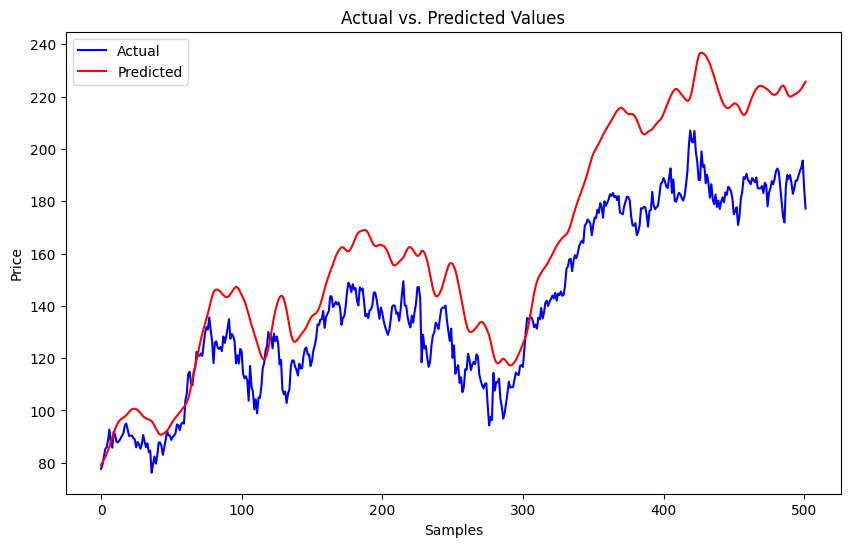

In [16]:
# actual values from the original dataset (unscaled)
actual = dataset[training_data_len:, 0]

plt.figure(figsize=(10, 6))
plt.plot(actual, label='Actual', color='blue')
plt.plot(predictions[:, 0], label='Predicted', color='red')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.show()

**Interpretation of the Prediction Results**

In the above plot, the blue line represents the actual values (the true price data), while the red line shows the model’s predictions. Here are some key observations:

1. **Overall Trend Capture**  
   The model’s predictions (red line) follow the general upward and downward trends of the actual data (blue line). This indicates that the LSTM has learned some of the temporal patterns and broader movements in the price data.

2. **Smoothing Effect**  
   The predicted values appear smoother compared to the actual values. This is common in time series models like LSTM, which often capture broader patterns but may struggle with sharp, short-term fluctuations.

3. **Potential Lag**  
   There may be a slight lag where the model’s predicted line follows the actual line with a small delay. This is another common characteristic in sequence prediction models, especially if the model is more attuned to recent history rather than instantaneous changes.

4. **Opportunities for Improvement**  
   - **Hyperparameter Tuning**: Adjusting the number of LSTM units, layers, or epochs may help the model learn finer-grained patterns.
   - **Feature Engineering**: Incorporating additional features (e.g., technical indicators, volume, or external data) can provide more context for the model.
   - **Data Preprocessing**: Trying different scaling methods or longer/shorter sequence lengths could improve responsiveness to rapid price changes.

Overall, the model seems to do a decent job of learning the overall structure of the time series but could benefit from further tuning or additional data to better capture short-term volatiliy and reduce lag.


### Exercise-02: Train a 2-layer bidirectional LSTM on the IMDB movie review sentiment classification dataset.

In [17]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import os

In [18]:
# Only consider the top 20k words
# Only consider the first 200 words of each movie review
max_features = 20000  
maxlen = 200

# Building a Sentiment Analysis Model with Bidirectional LSTMs

In this session, we'll create a model to classify movie reviews from the IMDB dataset. The model will handle variable-length sequences, embed words into a dense vector space, and use bidirectional LSTM layers before making a final classification. Follow these steps and we'll fill in the details during our live coding session.

---

## Step 1: Define the Input Layer

**Objective:** Create an input layer that accepts sequences of integers of variable length.

**Instructions:**
- Use an input layer that can handle variable-length sequences (i.e., shape set to `(None,)`).
- Specify the data type as `"int32"`.

---

## Step 2: Add the Embedding Layer

**Objective:** Map each integer in the sequence to a 128-dimensional vector.

**Instructions:**
- Insert an embedding layer that takes the input and transforms it into a dense representation.
- Set the embedding dimension to 128.
- Use `max_features` as the vocabulary size.

---

## Step 3: Build the Bidirectional LSTM Layers

**Objective:** Process the embedded sequences with bidirectional LSTMs.

**Instructions:**
- **First Bidirectional LSTM:**
  - Add a bidirectional LSTM layer with 64 units.
  - Enable `return_sequences=True` because another LSTM layer will follow.
- **Second Bidirectional LSTM:**
  - Add a second bidirectional LSTM layer with 64 units.
  - This layer does not need to return sequences since it feeds directly into the classifier.

---

## Step 4: Add the Classifier

**Objective:** Create a binary classifier that outputs a probability.

**Instructions:**
- Add a Dense layer with 1 unit.
- Use the `sigmoid` activation function to output a value between 0 and 1.

---

## Step 5: Create and Summarize the Model

**Objective:** Combine the layers into a complete model and review its architecture.

**Instructions:**
- Use the Keras `Model` API to define the model with the specified input and output layers.
- Display the model summary to ensure the architecture is correct.

---

## Step 6: Load and Prepare the IMDB Dataset

**Objective:** Load the dataset and prepare it for training.

**Instructions:**
- Load the IMDB movie review sentiment data, restricting the vocabulary using `num_words=max_features`.
- Split the data into training and validation sets.
- Print the number of training and validation sequences.
- Use the Keras preprocessing utilities to pad the sequences to a fixed length (`maxlen`).

---

## Step 7: Compile the Model

**Objective:** Configure the model for training.

**Instructions:**
- Compile the model using the `adam` optimizer.
- Set the loss function to binary cross-entropy, which is suitable for binary classification.
- Include accuracy as a metric.

---

## Step 8: Train the Model

**Objective:** Train the model on the prepared data.

**Instructions:**
- Train the model using the `fit()` method.
- Set the number of epochs to 2 and the batch size to 32.
- Provide the validation data to monitor performance during training.

---

#### QUICK TIP
if you are using a Mac M, you can check if TensorFlow is using GPU by running the following code:

print(tf.config.list_physical_devices())

if not, you can install tensorflow-metal.
after the installation restart the kernel and check again.
from now on when you import tensorflow it will automatically use the GPU if available.

for reference, on a Macbook M3 the last cell took 5 minutes CPU only and less than 3 minutes with GPU

In [19]:
# [TODO] Input for variable-length sequences of integers
inputs = keras.Input(shape=(None,), dtype="int32")

In [20]:
# [TODO]  Embed each integer in a 128-dimensional vector
x = layers.Embedding(max_features, 128)(inputs)

In [21]:
# [TODO] Add 2 bidirectional LSTMs
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)

In [22]:
# [TODO] Add a classifier, use Sigmoid as activation function
outputs = layers.Dense(1, activation ="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None)]            0         
                                                                 
 embedding (Embedding)       (None, None, 128)         2560000   
                                                                 
 bidirectional (Bidirection  (None, None, 128)         98816     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 128)               98816     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2757761 (10.52 MB)
Trainable params: 2757761 (1

### 💡 Detailed Code Explanation
| Component | Explanation |
|---|---|
| `Embedding(...)` | Learns a vector representation for each word index during training. |
| `Bidirectional(LSTM(...))` | Reads the sequence forward and backward and combines both representations. |
| Sigmoid output | Produces a probability for the positive class (binary classification). |

In [23]:
# [TODO] Load the IMDB movie review sentiment data
(x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(
    num_words=max_features
)
print(len(x_train), "Training sequence")
print(len(x_val), "Validation sequence")
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen) # we defined maxlen before
x_val = keras.preprocessing.sequence.pad_sequences(x_val, maxlen=maxlen)

25000 Training sequence
25000 Validation sequence


In [24]:
# [TODO] compile the model using adam optimizer and Binary cross-entropy as loss function
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

### 💡 Detailed Code Explanation
| Component | Explanation |
|---|---|
| `Adam` | optimization algorithm that adapts the learning rate during training. |
| `binary_crossentropy` | Measures how far the model's predictions are from the true labels (0 or 1), the lowe the better. |
| `accuracy` | percentage of correct predictions during training. |

In [25]:
# [TODO] train the model set epochs to 2, batch size to 32
#if you are struggling with the training, you can set batch size to 64 or 128 to speed up the training process
model.fit(x_train, y_train, batch_size=32, epochs=2, validation_data=(x_val, y_val))

Epoch 1/2
782/782 [==============================] - 91s 114ms/step - loss: 0.4187 - accuracy: 0.8087 - val_loss: 0.3575 - val_accuracy: 0.8471
Epoch 2/2
782/782 [==============================] - 86s 110ms/step - loss: 0.2381 - accuracy: 0.9116 - val_loss: 0.3548 - val_accuracy: 0.8470
